In [1]:
import os, gzip, prody
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

stats_dir = 'stats'
pdb_dir = '/mnt/hdd/yenlin/data/Protein_Data_Bank'
pdb_download_dir = f'{pdb_dir}/pdb.gz'
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

multimericities = np.arange(2, 7)

# PARAMETERS
coverage_mode = 0
# similarity_cutoff = 1
similarity_cutoff = 0.95

tag = f'sim_{similarity_cutoff}-PDB_ready'


In [2]:
### READ DATA FROM PREVIOUS SCRIPT

# META DATA
all_info = np.loadtxt(
    f'{stats_dir}/OUT-3-2.all_information-sim_{similarity_cutoff}-annotated.csv',
    delimiter=',',
    dtype=np.str_,
    comments=None
)

header = all_info[0].tolist()
header[0] = header[0][2:]
all_info = all_info[1:]

print(header)

# FASTA
with open(
    f'{stats_dir}/OUT-3-2.all_sequences-sim_{similarity_cutoff}-annotated.fasta',
    'r'
) as f:
    all_sequences = f.read().split('>')[1:]
all_sequences = np.array([
    entry.split('\n', 1)[1].replace('\n', '') for entry in all_sequences
])

print(all_sequences[1])

assert len(all_info) == len(all_sequences)
print()
print(len(all_info), 'entries')


['full_id', 'pdb_id', 'assembly_id', 'multimericity', 'auth_chain_id', 'asym_chain_id', 'seq_database', 'seq_database_accession']
AAAAANHSTQESGFDYEGLIDSELQKKRLDKSYRYFNNINRLAKEFPLAHRQREADKVTVWCSNDYLALSKHPEVLDAMHKTIDKYGCGAGGTRNIAGHNIPTLNLEAELATLHKKEGALVFSSCYVANDAVLSLLGQKMKDLVIFSDELNHASMIVGIKHANVKKHIFKHNDLNELEQLLQSYPKSVPKLIAFESVYSMAGSVADIEKICDLADKYGALTFLDEVHAVGLYGPHGAGVAEHCDFESHRASGIATPKTNDKGGAKTVMDRVDMITGTLGKSFGSVGGYVAASRKLIDWFRSFAPGFIFTTTLPPSVMAGATAAIRYQRCHIDLRTSQQKHTMYVKKAFHELGIPVIPNPSHIVPVLIGNADLAKQASDILINKHQIYVQAINFPTVARGTERLRITPTPGHTNDLSDILINAVDDVFNELQLPRVRDWESQGGLLGVGESGFVEESNLWTSSQLSLTNDDLNPNVRDPIVKQLEVSSGIKQ

11359 entries


In [3]:
### COLLATE DOWNLOADED PDB STRUCTURES

pdbs_in_download_dir = [
    f.split('.')[0] for f in os.listdir(pdb_download_dir)
    if f.endswith('.pdb.gz')
]
print(f'Number of PDB files in directory: {len(pdbs_in_download_dir)}')

pdbs_to_process = [
    pdb_id for pdb_id in pdbs_in_download_dir
    if pdb_id in all_info[:, header.index('pdb_id')]
]
print(f'Number of PDB files in target list: {len(pdbs_to_process)}')

full_ids_to_process = [
    full_id for full_id in all_info[:, header.index('full_id')]
    if full_id[:4] in pdbs_to_process
]
print()
print(f'Number of entries to process: {len(full_ids_to_process)}')

all_info_to_process = all_info[
    np.isin(all_info[:, header.index('full_id')], full_ids_to_process)
]
all_sequences_to_process = all_sequences[
    np.isin(all_info[:, header.index('full_id')], full_ids_to_process)
]
_, cnt = np.unique(
    all_info_to_process[:,header.index('multimericity')].astype(np.int_),
    return_counts=True
)
print(cnt, np.sum(cnt))


Number of PDB files in directory: 26760
Number of PDB files in target list: 11241

Number of entries to process: 11241
[8149  870 1651   77  494] 11241


In [4]:
### SUMMARIZE

# ENTRIES THAT DOES NOT REQUIRE BIOMT TRANSFORMS
all_multimericity_to_process = all_info_to_process[:,header.index('multimericity')].astype(np.int_)
all_auth_chain_ids_to_process = all_info_to_process[:,header.index('auth_chain_id')]

all_n_chains_specified = np.array([
    len(auth_chain_id.split('_')) for auth_chain_id in all_auth_chain_ids_to_process
])
num = np.count_nonzero(all_multimericity_to_process == all_n_chains_specified)
print(f'Entries that does not require BIOMT transforms: {num}')
print(
    f'Entries that require BIOMT transforms: '
    f'{len(all_info_to_process)-num}'
)
# print(f'Total number of entires: {len(all_info_to_process)}')

print()

# ENTRIES WHERE THE NUMBER OF CHAINS SPECIFED IS LARGER THAT THE MULTIMERICITY
num = np.count_nonzero(all_multimericity_to_process < all_n_chains_specified)
print(f'Entries where # chains is larger than multimericity: {num}')
print(all_info_to_process[
    all_multimericity_to_process < all_n_chains_specified,
    header.index('full_id')
])


Entries that does not require BIOMT transforms: 5618
Entries that require BIOMT transforms: 5623

Entries where # chains is larger than multimericity: 1864
['1B37-6' '1D5N-1' '1E5Z-1' ... '8I09-1' '8PNM-2' '9FEK-2']


In [5]:
### UNARCHIVE

saved_entries = []
entries_with_BIOMT_remarks = []

for full_id in tqdm(all_info_to_process[:,header.index('full_id')], ascii=True):
    pdb_id = full_id[:4].upper()

    pdb_gz_file = f'{pdb_download_dir}/{pdb_id}.pdb.gz'
    save_file = f'{pdb_dir}/pdb/{pdb_id}.pdb'

    if not os.path.exists(save_file):

        # check if pdb.gz exists
        if not os.path.exists(pdb_gz_file):
            print(f'{pdb_id}.pdb.gz not found')

        # read pdb.gz
        with gzip.open(pdb_gz_file, 'rt') as f:
            lines = f.readlines()

        # save as pdb (text)
        with open(save_file, 'w') as f:
            f.writelines(lines)

    with open(save_file, 'r') as f:
        lines = f.readlines()

    # check for BIOMT REMARKS
    if any(['REMARK 350' in line for line in lines]):
        entries_with_BIOMT_remarks.append(full_id)
    else:
        # remove file
        os.remove(save_file)

    saved_entries.append(full_id)

print('# entries with BIOMT remarks:', len(entries_with_BIOMT_remarks))
print('# entries saved:', len(saved_entries))


100%|##########| 11241/11241 [03:28<00:00, 54.01it/s]

# entries with BIOMT remarks: 11241
# entries saved: 11241


In [6]:
### PARSE BIOMT REMARKS AND APPLY

entries_processed = []
entries_that_failed = []
n_chains_in_final_pdb = []
identical_chains = []

pbar = tqdm(all_info_to_process[:,header.index('full_id')], ascii=True)
for idx, full_id in enumerate(pbar):
    # pbar.set_description(full_id)
    # if idx > 9:
    #     break
    # if full_id != '1A05-1':
    #     continue
    pdb_id = full_id[:4].upper()
    assembly_id = full_id.split('-')[-1]

    pdb_input_file = f'{pdb_dir}/pdb/{pdb_id}.pdb'
    pdb_output_file = f'{pdb_dir}/pdb-biomt/{pdb_id}-{assembly_id}.pdb'

    # if pdb_id not in ['2Q48']:
    #     continue
    # print(full_id)

    # CHECK IF OUTPUT EXISTS
    abort = False
    if not os.path.exists(pdb_output_file):
        pbar.set_description(f'Processing {full_id}')

        ################################################################
        # GET TRANSFORM MATRIX
        ################################################################
        with open(pdb_input_file, 'r') as f:
            lines = [l.replace('\n', '') for l in f.readlines()]

        assemblies = {}
        for line_idx, line in enumerate(lines):
            if not line.startswith('REMARK 350'):
                continue

            remark = line[11:]
            if remark.startswith('BIOMOLECULE:'):
                auth_assembly_id = remark.split()[1]
                assemblies[auth_assembly_id] = []

            elif remark.startswith('APPLY THE FOLLOWING TO CHAINS:'):
                auth_chains_to_apply_to = [
                    elem.replace(',', '') for elem in remark.split()[5:]
                ]
                biomt_transforms = []

            elif remark.startswith('  BIOMT1'):
                biomt_transforms.append(np.identity(4))
                biomt_transforms[-1][0,] = remark.split()[2:]
            elif remark.startswith('  BIOMT2'):
                biomt_transforms[-1][1,] = remark.split()[2:]
            elif remark.startswith('  BIOMT3'):
                biomt_transforms[-1][2,] = remark.split()[2:]

                if not lines[line_idx+1].startswith('REMARK 350   BIOMT1'):
                    assemblies[auth_assembly_id].append(
                        {
                            'chains': auth_chains_to_apply_to,
                            'biomt_transforms': biomt_transforms}
                    )

        ################################################################
        # APPLY TRANSFORM
        ################################################################

        all_transforms = assemblies[assembly_id]
        # print(all_transforms)

        atoms = prody.parsePDB(pdb_input_file)
        peptide_chains_in_pdb = np.unique(
            atoms.select('protein').getChids()
        )

        atoms_merged = None
        new_chain_id = 'A'
        for transform in all_transforms:
            auth_chains_to_apply_to = transform['chains']
            biomt_transforms_for_chains = transform['biomt_transforms']

            for auth_chain_id in auth_chains_to_apply_to:
                # print(f'Chain {auth_chain_id}')
                if auth_chain_id not in peptide_chains_in_pdb:
                    continue

                for biomt_idx, biomt in enumerate(biomt_transforms_for_chains):
                    # print(f'  Transform {biomt_idx+1}')
                    transformation = prody.Transformation(biomt)

                    atoms_chain = prody.parsePDB(
                        pdb_input_file,
                        chain=auth_chain_id
                    ).select('protein')
                    if atoms_chain is None:
                        abort = True
                        entries_that_failed.append([full_id, 'atoms is None'])
                        break

                    prody.applyTransformation(
                        transformation,
                        atoms_chain
                    )

                    atoms_chain.setChids(new_chain_id)
                    new_chain_id = chr(ord(new_chain_id)+1)

                    if atoms_merged is None:
                        atoms_merged = atoms_chain.copy()
                    else:
                        try:
                            atoms_merged += atoms_chain.copy()
                        except ValueError as err:
                            abort = True
                            entries_that_failed.append([full_id, str(err)])
                            break

                if abort:
                    break
            if abort:
                break
        if abort:
            continue

        prody.writePDB(pdb_output_file, atoms_merged)

    ####################################################################
    # SUMMARIZE
    ####################################################################

    atoms_transformed = prody.parsePDB(pdb_output_file)

    n_chains_in_final_pdb.append(atoms_transformed.numChains())

    all_sequences = []
    all_resnums = []
    for chain in atoms_transformed.iterChains():
        all_sequences.append(chain.getSequence(allres=False))
        all_resnums.append(chain.getResnums())

    # CHECK IF SEQUENCES ARE IDENTICAL
    if len(np.unique(all_sequences)) == 1:
        identical_chains.append(full_id)

    entries_processed.append(full_id)

    # break

print(f'# entries processed: {len(entries_processed)}')
print(f'# entries discarded: {len(entries_that_failed)}')
print()
print(f'# entries where all chains have exactly identical sequences: {len(identical_chains)}')

print('Non-identical chains:')
print(np.setdiff1d(entries_processed, identical_chains))


100%|##########| 11241/11241 [06:22<00:00, 29.35it/s]

# entries processed: 11241
# entries discarded: 0

# entries where all chains have exactly identical sequences: 5996
Non-identical chains:
['1A0G-1' '1A3A-2' '1A92-3' ... '9QUU-1' '9R8S-1' '9UDB-1']


In [7]:
entries_that_failed

[]

In [8]:
### QC

########################################################################
# MULTIMERICITY IN PDB VS MULTIMERICITY SPECIFIED
########################################################################

multimericity_mismatch = []
loc = header.index('multimericity')
for entry_idx, full_id in enumerate(entries_processed):
    if int(all_info_to_process[entry_idx,loc]) != n_chains_in_final_pdb[entry_idx]:
        multimericity_mismatch.append([
            full_id,
            (all_info_to_process[entry_idx,loc]),
            (n_chains_in_final_pdb[entry_idx])
        ])
        # print(multimericity_mismatch[-1])

print(f'# chains in PDB does not match multimericity specified: '
      f'{len(multimericity_mismatch)} entries')
multimericity_mismatch = np.array(multimericity_mismatch)

remaining_entries = np.setdiff1d(
    entries_processed,
    multimericity_mismatch[:,0]
)
print(f'# entries remaining: {len(remaining_entries)}')
print()


# EXAMINE RESNUMS
duplicate_resnums = []
no_intersection = []
mismatched_shared_residues = []
pbar = tqdm(remaining_entries,ascii=True)
for entry_idx, full_id in enumerate(pbar):
    pbar.set_description(full_id)

    atoms = prody.parsePDB(
        f'{pdb_dir}/pdb-biomt/{full_id}.pdb',
        subset='calpha'
    )

    all_sequences = []
    all_resnums = []
    # all_occupancies = []
    for chain_idx, chain in enumerate(atoms.iterChains()):
        all_sequences.append(np.array([c for c in chain.getSequence(allres=False)]))
        all_resnums.append(chain.getResnums())
        # all_occupancies.append(chain.getOccupancies())

    ####################################################################
    # RESNUM HAS OVER ONE OCCURENCE IN CHAIN
    ####################################################################
    abort = False
    for chain_idx in range(atoms.numChains()):
        if len(np.unique(all_resnums[chain_idx])) != len(all_resnums[chain_idx]):
            duplicate_resnums.append(full_id)
            abort = True
            continue
    if abort:
        continue

    ####################################################################
    # AN INTERSECTION OF RESNUMS EXIST AMONG ALL CHAINS
    ####################################################################
    resnum_unique, resnum_count = np.unique([
        resnum for resnum_of_chain in all_resnums
        for resnum in resnum_of_chain
    ], return_counts=True)
    resnum_intersection = resnum_unique[resnum_count == atoms.numChains()]
    # print(len(resnum_intersection), 'residues in intersection')
    if len(resnum_intersection) == 0:
        no_intersection.append(full_id)
        continue

    ####################################################################
    # SHARED SEGMENTS HAVE DIFFERENT SEQUENCES
    ####################################################################
    for chain1_idx in range(atoms.numChains()):
        for chain2_idx in range(chain1_idx+1, atoms.numChains()):

            loc = np.intersect1d(
                all_resnums[chain1_idx],
                all_resnums[chain2_idx],
                assume_unique=True,
            )

            # assert that the residues are the same
            seq1_shared = all_sequences[chain1_idx][np.isin(all_resnums[chain1_idx], loc, assume_unique=True)]
            seq2_shared = all_sequences[chain2_idx][np.isin(all_resnums[chain2_idx], loc, assume_unique=True)]
            assert len(seq1_shared) == len(seq2_shared), f'{full_id} {chain1_idx}-{chain2_idx} {len(seq1_shared)} != {len(seq2_shared)}'

            if not np.array_equal(seq1_shared, seq2_shared):
                mismatched_shared_residues.append([full_id, f'{chain1_idx}-{chain2_idx}'])

duplicate_resnums = np.unique(duplicate_resnums)
no_intersection = np.array(no_intersection)
mismatched_shared_residues = np.array(mismatched_shared_residues)

print(f'resnums with duplicates: {len(duplicate_resnums)}')
print(f'entries with no intersection of resnums: {len(no_intersection)}')
print(f'shared resnums have different sequences: {len(np.unique(mismatched_shared_residues[:,0]))}')

# SUMMARIZE
entries_to_keep = [
    e for e in entries_processed
    if e not in np.concatenate((
        multimericity_mismatch[:,0],
        duplicate_resnums,
        no_intersection,
        mismatched_shared_residues[:,0]
    ))
]
print()
print(f'# entries to keep: {len(entries_to_keep)}')


# chains in PDB does not match multimericity specified: 18 entries
# entries remaining: 11223



1AJ8-1:   0%|          | 30/11223 [00:00<01:24, 133.01it/s]

9WGA-3: 100%|##########| 11223/11223 [08:57<00:00, 20.88it/s]

resnums with duplicates: 71
entries with no intersection of resnums: 91
shared resnums have different sequences: 18

# entries to keep: 11043


In [9]:
### SUMMARIZE RESULTS

loc = np.isin(all_info_to_process[:,header.index('full_id')], entries_to_keep)
all_info_to_keep = all_info_to_process[loc]
all_sequences_to_keep = all_sequences_to_process[loc]

_, cnt = np.unique(
    all_info_to_keep[:, header.index('multimericity')].astype(int),
    return_counts=True
)
print('# entries after BIOMT')
print(cnt, np.sum(cnt))


# entries after BIOMT
[8022  862 1597   74  488] 11043


In [10]:
### SAVE INFO

np.savetxt(
    f'{stats_dir}/OUT-5.all_information-{tag}.csv',
    all_info_to_keep,
    delimiter=',',
    fmt='%s',
    header=','.join(header)
)

# FASTA
all_auth_chain_id_to_keep = all_info_to_keep[:,header.index('auth_chain_id')]
all_asym_chain_id_to_keep = all_info_to_keep[:,header.index('asym_chain_id')]
with open(f'{stats_dir}/OUT-5.all_sequences-{tag}.fasta', 'w') as f:
    for assembly_idx in range(len(all_sequences_to_keep)):
        f.write(
            f'>{all_info_to_keep[assembly_idx,header.index("full_id")]},'
            f'auth_chain_id:{all_auth_chain_id_to_keep[assembly_idx]},'
            f'asym_chain_id:{all_asym_chain_id_to_keep[assembly_idx]}\n'
        )
        f.write(f'{all_sequences_to_keep[assembly_idx]}\n')


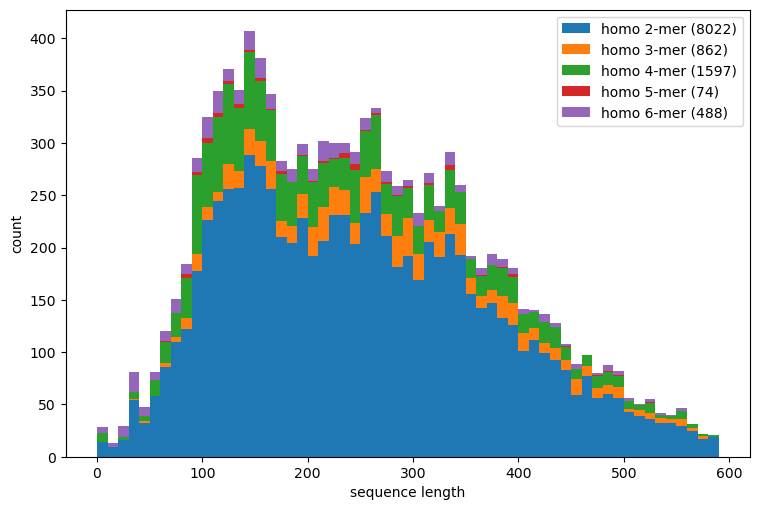

In [ ]:

### Data count

all_lengths = [
    len(seq) for seq in all_sequences_to_keep
]

lengths_by_multimericity = []
multimericities_to_keep = all_info_to_keep[:,header.index('multimericity')].astype(np.int_)
for m in multimericities:
    idx = ( multimericities_to_keep == m )
    lengths_by_multimericity.append([len(seq) for seq in all_sequences_to_keep[idx]])

# PLOT
fig, ax = plt.subplots(figsize=(7.48, 7.48/3*2), layout='compressed')
ax.hist(
    lengths_by_multimericity,
    stacked=True,
    label=[
        f'homo {m}-mer ({np.count_nonzero(multimericities_to_keep == m)})'
        for m in multimericities
    ],
    # edgecolor='white',
    bins=np.arange(60)*10
)
ax.set_xlabel('sequence length')
ax.set_ylabel('count')
# ax.set_xlim(0,600)
ax.legend()

plt.savefig(
    f'{plots_dir}/OUT-5.histogram - seq length.png',
    dpi=300
)
plt.show()
plt.close()
